# 04 - Multi-Object Tracking

Tracking con salida tabular, calculo de trayectorias y ploteo directo. Las celdas de inferencia estan comentadas para que puedas activar un video real.


In [1]:
from vision.yolo.track import (
    track_video,
    build_tracks_dataframe,
    compute_track_statistics,
    smooth_tracks,
    filter_short_tracks,
)
from vision.yolo.video import (
    video_frame_generator,
    write_video_predictions,
    write_annotated_video,
    write_annotated_video_from_dataframe,
    get_video_info,
)
from vision.yolo.infer import predict_video
from vision.yolo.plotting import plot_video_statistics, plot_class_distribution

print("Librerias cargadas")


Librerias cargadas


In [2]:
import os

# Ejecutar tracking sobre un video real
VIDEO = "input/samid_viale.mp4"  # Cambia esto a la ruta de tu video

print(f"Processing video: {VIDEO}")
# check if the video file exists
# check if the video is a URL or a local file
if VIDEO.startswith("http"):
    print(f"Video is a URL: {VIDEO}")
    # check if URL is reachable
    import requests

    try:
        response = requests.get(VIDEO)
        if response.status_code == 200:
            print("URL is reachable.")
        else:
            print(f"URL is not reachable. Status code: {response.status_code}")
    except requests.RequestException as e:
        print(f"Error occurred while checking URL: {e}")
else:
    if not os.path.exists(VIDEO):
        print(f"Video file {VIDEO} does not exist.")
    else:
        print(f"Video file {VIDEO} exists.")
        info = get_video_info(VIDEO)
        for key, value in info.items():
            print(f"{key}: {value}")


Processing video: input/samid_viale.mp4
Video file input/samid_viale.mp4 exists.
path: input/samid_viale.mp4
width: 720
height: 1280
fps: 30.0
frame_count: 4556
duration_s: 151.86666666666667


In [3]:
from vision.yolo.track import track_video

MODEL = "yolo26s-pose.pt"

raw = track_video(
    MODEL,
    VIDEO,
    tracker="bytetrack.yaml",
    confidence=0.25,
    device="cuda"
)
print(raw.head())


/home/juan/miniforge3/envs/ultralytics/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


   frame track_id  class_id class_name  confidence        xmin        ymin  \
0      0        1         0     person    0.888411  147.884171  379.535858   
1      0        2         0     person    0.694026   43.566711   35.447327   
2      1        1         0     person    0.887664  149.884109  380.587341   
3      1        2         0     person    0.696542   42.478344   37.451977   
4      2        1         0     person    0.884934  150.030991  381.289978   

         xmax        ymax polygon  mask  \
0  588.320923  893.643311    None  None   
1  511.337891  379.043823    None  None   
2  589.162476  893.341003    None  None   
3  507.323517  378.888519    None  None   
4  588.511353  893.222351    None  None   

                                           keypoints  timestamp  
0  [[330.5411682128906, 527.6632690429688, 0.9969...   0.000000  
1  [[282.29400634765625, 352.947265625, 0.6495556...   0.000000  
2  [[331.7306823730469, 528.0860595703125, 0.9968...   0.033333  
3  [[282

In [4]:
# Ejemplo minimo sin modelo para probar el analisis
tracks = build_tracks_dataframe(raw)

print(tracks.head())


   frame track_id  class_id class_name  confidence        xmin        ymin  \
0      0        1         0     person    0.888411  147.884171  379.535858   
1      1        1         0     person    0.887664  149.884109  380.587341   
2      2        1         0     person    0.884934  150.030991  381.289978   
3      3        1         0     person    0.883047  149.467438  380.956390   
4      4        1         0     person    0.882641  149.304489  381.068939   

         xmax        ymax polygon  mask  \
0  588.320923  893.643311    None  None   
1  589.162476  893.341003    None  None   
2  588.511353  893.222351    None  None   
3  587.992676  893.167114    None  None   
4  587.341064  893.155579    None  None   

                                           keypoints  timestamp    x_center  \
0  [[330.5411682128906, 527.6632690429688, 0.9969...   0.000000  368.102547   
1  [[331.7306823730469, 528.0860595703125, 0.9968...   0.033333  369.523293   
2  [[332.92828369140625, 528.382324

In [6]:
stats = compute_track_statistics(tracks)

print(stats)

long_tracks = filter_short_tracks(tracks, min_frames=3)

smoothed = smooth_tracks(long_tracks, window=2)


     track_id class_name  frames  max_confidence  mean_confidence  \
0           1     person      28        0.888514         0.885031   
1           2     person      28        0.696542         0.674506   
2           3     person      79        0.898234         0.882731   
3           4     person      79        0.843430         0.760095   
4           9     person      62        0.545062         0.375914   
..        ...        ...     ...             ...              ...   
116       287     person      29        0.861627         0.796678   
117       288     person       1        0.383239         0.383239   
118       289     person       5        0.739392         0.414192   
119       292     person      28        0.864922         0.746967   
120       294     person      11        0.738795         0.575600   

     max_velocity  mean_velocity  trajectory_length  time_alive  
0       44.078923      17.508281          15.757452    0.900000  
1      123.650250      32.246064       

x: 31.567785263061523 679.5644226074219
y: 137.3089747428894 1191.7310180664062
tracks: 100
rows: 9339


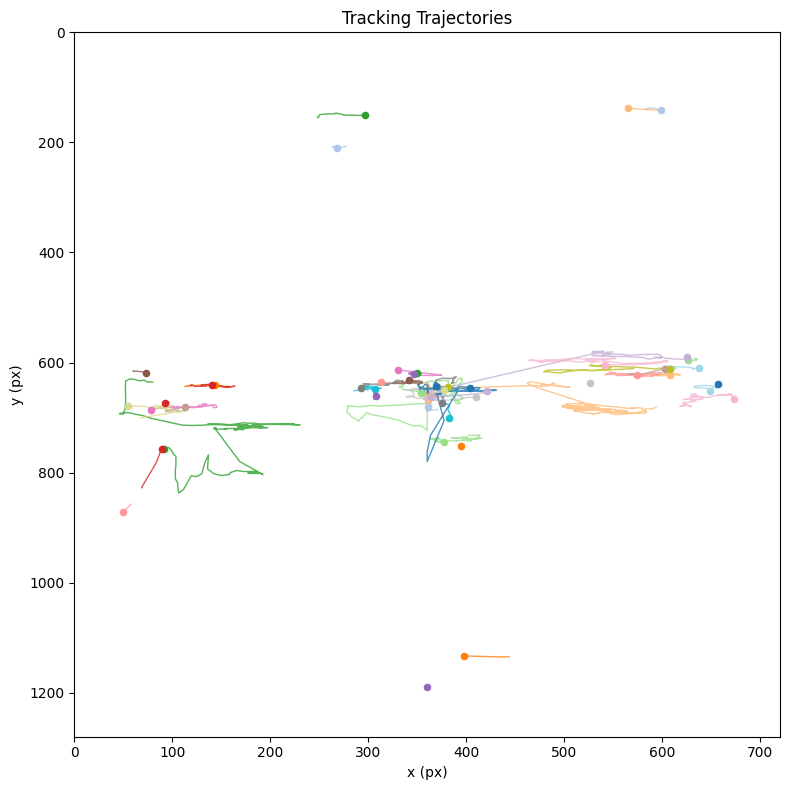

In [7]:
from vision.yolo.plotting import plot_tracking_trajectories

print("x:", long_tracks["x_center"].min(), long_tracks["x_center"].max())
print("y:", long_tracks["y_center"].min(), long_tracks["y_center"].max())
print("tracks:", long_tracks["track_id"].nunique())
print("rows:", len(long_tracks))


plot_tracking_trajectories(
    long_tracks,
    image_width=info["width"],
    image_height=info["height"],
)


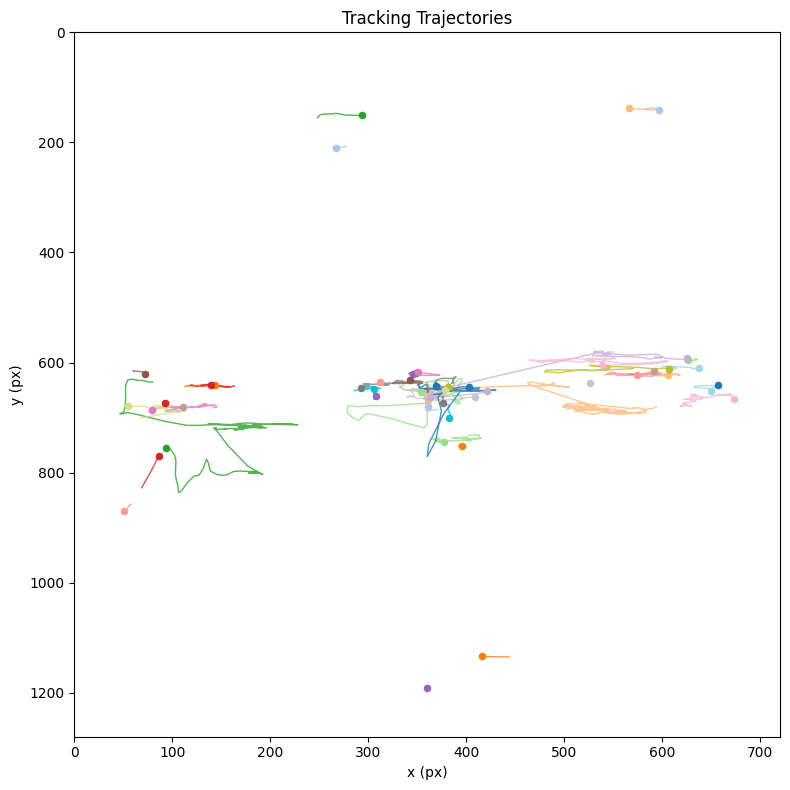

In [8]:
plot_tracking_trajectories(
    smoothed,  # mejor que long_tracks si ya calculaste smoothing
    image_width=info["width"],
    image_height=info["height"],

)


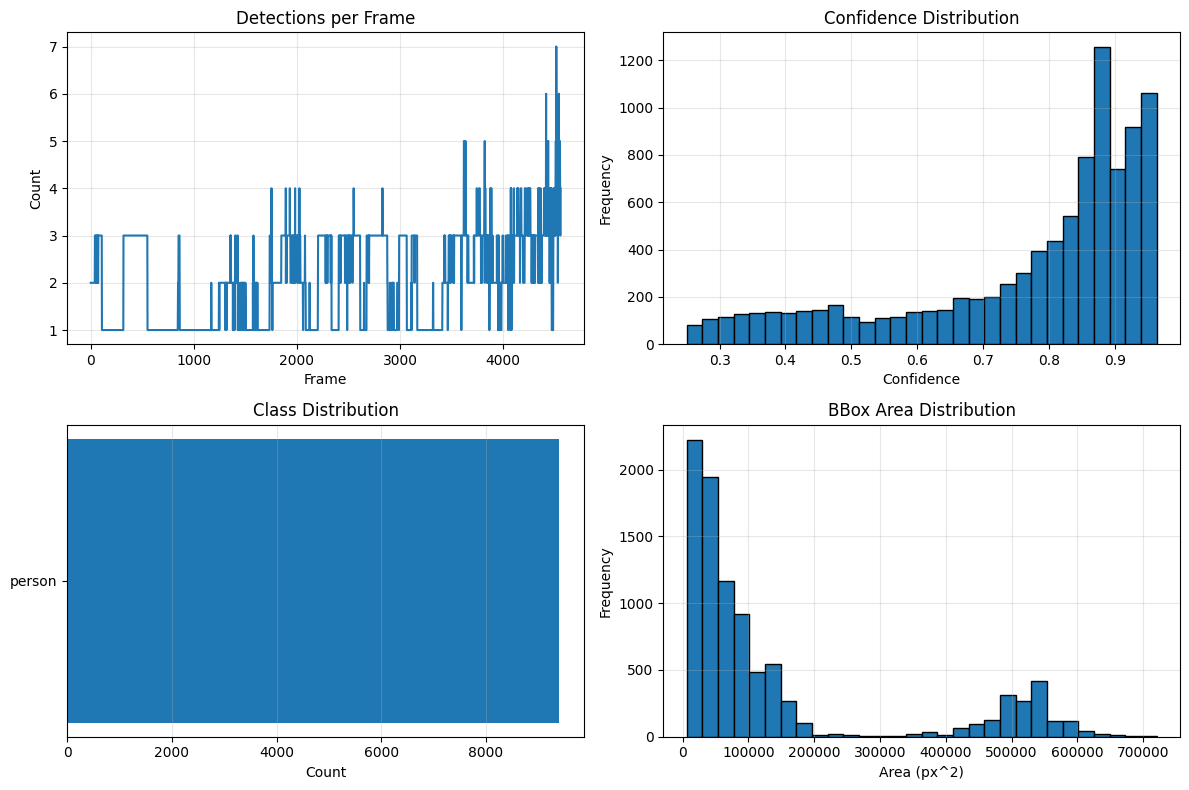

In [9]:
plot_video_statistics(raw)


In [10]:
annotated_video = write_annotated_video_from_dataframe(
    video_path=VIDEO,
    predictions=long_tracks,
    output_path="outputs/04_tracked_annotated_raw.mp4",
    color_by="track_id",
    draw_tails=False,
    tail_length=40,
    draw_boxes=False,
    annotation_workers=6,
    annotation_batch_size=64,
)


In [ ]:
import numpy as np
from collections import defaultdict, deque

from vision.yolo.video import draw_predictions_on_frame
from vision.yolo.video_io import write_frames

width = info["width"]
height = info["height"]
fps = info["fps"]
frame_count = info["frame_count"]

tail_length = 50

tail_history = defaultdict(lambda: deque(maxlen=tail_length))


def annotated_frames():

    for frame_idx in range(frame_count):

        # fondo negro
        canvas = np.zeros((height, width, 3), dtype=np.uint8)

        annotated = draw_predictions_on_frame(
            canvas,
            smoothed,
            frame_idx=frame_idx,
            color_by="class",
            draw_boxes=False,
            draw_labels=True,
            draw_polygons=False,
            draw_keypoints=True,
            draw_tails=True,
            tail_history=tail_history,
            tail_length=tail_length,
            box_thickness=3,
            label_scale=0.7,
        )

        yield annotated


write_frames(
    annotated_frames(),
    "outputs/04_tracks_black_background.mp4",
    fps=fps,
)


In [ ]:
import cv2

INPUT = "outputs/04_tracks_black_background.mp4"
OUTPUT = "outputs/04_tracked_black_annotated_small.mp4"

scale = 0.5  # 50% ancho y alto
target_fps = 25  # bajar de 25/30 fps a 25

cap = cv2.VideoCapture(INPUT)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

new_width = int(width * scale)
new_height = int(height * scale)

writer = cv2.VideoWriter(
    OUTPUT,
    cv2.VideoWriter_fourcc(*"mp4v"),
    target_fps,
    (new_width, new_height),
)

frame_interval = max(1, round(fps / target_fps))

frame_idx = 0

while True:
    ok, frame = cap.read()

    if not ok:
        break

    if frame_idx % frame_interval == 0:
        small = cv2.resize(
            frame,
            (new_width, new_height),
            interpolation=cv2.INTER_AREA,
        )

        writer.write(small)

    frame_idx += 1

cap.release()
writer.release()

print(OUTPUT)


In [ ]:
import cv2
import numpy as np
import pandas as pd

from vision.yolo.video_io import write_frames

# COCO 17 keypoints
# 0 nose
# 1 left_eye
# 2 right_eye
# 3 left_ear
# 4 right_ear
# 5 left_shoulder
# 6 right_shoulder
# 7 left_elbow
# 8 right_elbow
# 9 left_wrist
# 10 right_wrist
# 11 left_hip
# 12 right_hip
# 13 left_knee
# 14 right_knee
# 15 left_ankle
# 16 right_ankle

SKELETON = [
    (5, 7),
    (7, 9),  # brazo izq
    (6, 8),
    (8, 10),  # brazo der
    (5, 6),  # hombros
    (11, 12),  # caderas
    (5, 11),
    (6, 12),  # torso
    (11, 13),
    (13, 15),  # pierna izq
    (12, 14),
    (14, 16),  # pierna der
]


def parse_keypoints(value):
    if value is None:
        return np.empty((0, 3), dtype=float)

    arr = np.asarray(value, dtype=float)

    if arr.ndim != 2 or arr.shape[1] < 2:
        return np.empty((0, 3), dtype=float)

    if arr.shape[1] == 2:
        vis = np.ones((arr.shape[0], 1), dtype=float)
        arr = np.hstack([arr, vis])

    return arr[:, :3]


def kp_valid(kps, idx, thr=0.25):
    if idx >= len(kps):
        return False
    x, y, v = kps[idx]
    return np.isfinite(x) and np.isfinite(y) and (v >= thr)


def kp_xy(kps, idx):
    return tuple(np.round(kps[idx, :2]).astype(int))


def midpoint(p1, p2):
    return (
        int(round((p1[0] + p2[0]) / 2)),
        int(round((p1[1] + p2[1]) / 2)),
    )


def track_color(track_id):
    if pd.isna(track_id):
        return (0, 255, 255)

    tid = int(track_id)
    palette = [
        (255, 80, 80),
        (80, 255, 80),
        (80, 80, 255),
        (255, 180, 80),
        (255, 80, 255),
        (80, 255, 255),
        (200, 200, 80),
        (180, 120, 255),
    ]
    return palette[tid % len(palette)]


def draw_thick_line(img, p1, p2, color, thickness):
    cv2.line(img, p1, p2, color, thickness, lineType=cv2.LINE_AA)


def draw_joint(img, p, color, radius):
    cv2.circle(img, p, radius, color, -1, lineType=cv2.LINE_AA)


def draw_doodle_person(img, row, conf_thr=0.25):
    kps = parse_keypoints(row["keypoints"])
    if len(kps) == 0:
        return img

    # color = track_color(row.get("track_id", np.nan))
    color = (0, 0, 0)  # negro

    arm_thickness = 15
    leg_thickness = 17
    torso_thickness = 24
    joint_radius = 7

    # --- cabeza: óvalo ---
    head_center = None

    face_points = []
    for idx in [0, 1, 2, 3, 4]:
        if kp_valid(kps, idx, conf_thr):
            face_points.append(kp_xy(kps, idx))

    if len(face_points) > 0:
        xs = [p[0] for p in face_points]
        ys = [p[1] for p in face_points]
        head_center = (int(np.mean(xs)), int(np.mean(ys)))
    elif kp_valid(kps, 5, conf_thr) and kp_valid(kps, 6, conf_thr):
        shoulder_mid = midpoint(kp_xy(kps, 5), kp_xy(kps, 6))
        shoulder_dist = np.linalg.norm(kps[5, :2] - kps[6, :2])
        head_center = (
            shoulder_mid[0],
            int(round(shoulder_mid[1] - 0.35 * shoulder_dist)),
        )

    if kp_valid(kps, 5, conf_thr) and kp_valid(kps, 6, conf_thr):
        shoulder_dist = np.linalg.norm(kps[5, :2] - kps[6, :2])
        head_w = max(18, int(round(0.45 * shoulder_dist)))
        head_h = max(24, int(round(0.60 * shoulder_dist)))
    else:
        head_w = 24
        head_h = 32

    if head_center is not None:
        cv2.ellipse(
            img,
            head_center,
            (head_w, head_h),
            0,
            0,
            360,
            color,
            -1,
            lineType=cv2.LINE_AA,
        )
        cv2.ellipse(
            img,
            head_center,
            (head_w, head_h),
            0,
            0,
            360,
            (128, 128, 128),
            2,
            lineType=cv2.LINE_AA,
        )

    # --- torso simplificado ---
    if kp_valid(kps, 5, conf_thr) and kp_valid(kps, 6, conf_thr):
        left_shoulder = kp_xy(kps, 5)
        right_shoulder = kp_xy(kps, 6)
        shoulder_mid = midpoint(left_shoulder, right_shoulder)

        draw_thick_line(img, left_shoulder, right_shoulder, color, torso_thickness)

        if kp_valid(kps, 11, conf_thr) and kp_valid(kps, 12, conf_thr):
            left_hip = kp_xy(kps, 11)
            right_hip = kp_xy(kps, 12)
            hip_mid = midpoint(left_hip, right_hip)

            draw_thick_line(img, left_hip, right_hip, color, torso_thickness)
            draw_thick_line(img, shoulder_mid, hip_mid, color, torso_thickness)

    # --- extremidades gruesas ---
    for a, b in SKELETON:
        if kp_valid(kps, a, conf_thr) and kp_valid(kps, b, conf_thr):
            p1 = kp_xy(kps, a)
            p2 = kp_xy(kps, b)

            if (a, b) in [(5, 7), (7, 9), (6, 8), (8, 10)]:
                thickness = arm_thickness
            elif (a, b) in [(11, 13), (13, 15), (12, 14), (14, 16)]:
                thickness = leg_thickness
            else:
                thickness = torso_thickness

            draw_thick_line(img, p1, p2, color, thickness)

    # --- articulaciones como círculos ---
    for idx in [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]:
        if kp_valid(kps, idx, conf_thr):
            draw_joint(img, kp_xy(kps, idx), (128, 128, 128), joint_radius)
            draw_joint(img, kp_xy(kps, idx), color, joint_radius - 2)

    return img


In [ ]:
pose_df = smoothed.copy()

width = info["width"]
height = info["height"]
fps = info["fps"]
frame_count = info["frame_count"]

background = "white"  # "black" o "white"


def doodle_frames():
    for frame_idx in range(frame_count):

        if background == "black":
            canvas = np.zeros((height, width, 3), dtype=np.uint8)
        else:
            canvas = np.full((height, width, 3), 255, dtype=np.uint8)

        frame_data = pose_df[pose_df["frame"] == frame_idx]

        for _, row in frame_data.iterrows():
            draw_doodle_person(canvas, row, conf_thr=0.25)

        yield canvas


write_frames(
    doodle_frames(),
    "outputs/pose_doodle.mp4",
    fps=fps,
)


In [ ]:
import subprocess

ORIGINAL = "input/samid_viale.mp4"
DOODLE = "outputs/04_tracked_black_annotated_small.mp4"
OUTPUT = "outputs/pose_doodle_with_audio.mp4"

subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-i",
        DOODLE,
        "-i",
        ORIGINAL,
        "-map",
        "0:v:0",  # video del doodle
        "-map",
        "1:a:0?",  # audio del original, si existe
        "-c:v",
        "copy",
        "-c:a",
        "aac",
        "-b:a",
        "128k",
        "-shortest",
        OUTPUT,
    ],
    check=True,
)

print(OUTPUT)
